# Low Fidelity Neural Network
Neural Network which uses LF dataset and exploits the Low fidelity component of the MF model. The NN is tested also on the HF test set  

In [2]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from keras.utils import custom_object_scope
from keras.initializers import glorot_uniform
from keras.models import load_model, save_model
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions import (
    getModel,
    kCrossVal,
    transfBestparam,
    kCrossValSingle,
    import_data, normalization
)
from time import perf_counter
import pandas
import os
import keras
import tensorflow as tf

In [3]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

# Data Preparation

In [4]:
file_path_LF = "../DATA/reaction_diffusion_LF_46_d75.mat"
(reaction_LF_test, U_LF_test) = import_data(file_path_LF)

NepoLF = 8000  # number of epochs for second NN: NN_HF


reaction_LF_test = normalization(reaction_LF_test)
U_LF_test = U_LF_test[:, -1, 12,12]
U_LF_test=normalization(U_LF_test)

In [5]:
# randomization
Nlf = 30
permutation = np.random.permutation(len(reaction_LF_test))
reaction_LF = reaction_LF_test[permutation][0:Nlf]
U_LF = U_LF_test[permutation][0:Nlf]

reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]



# Low Fidelity Neural Network
## Low fidelity data

In [6]:
start = perf_counter()

#reaction_final = np.vstack(
#    (reaction_LF)
#)  

name="LF"
K.clear_session()
best_params = {
                    "lr": 0.0255,
                    "kernel_init": "glorot_uniform",
                    "opt": "Adam",
                } 
print(best_params)


{'lr': 0.0255, 'kernel_init': 'glorot_uniform', 'opt': 'Adam'}


In [7]:
# start = perf_counter()

# reaction_final = np.vstack(
#     (reaction_LF)
# )  

# ##########################       NN_LF     ##########################
# ####################    HYPERPARAMETER OPTIMIZATION    #######################
# MAX_EVAL = 15
# name = "LF"
# K.clear_session()
# bayes_trials = Trials()
# opt_list = ["Adam", "Adamax"]
# kernel_list = ["uniform", "glorot_uniform"]
# aux_dic = {"opt": opt_list, "kernel_init": kernel_list}
# space = {
#     "nodes": hp.qloguniform("nodes", np.log(4), np.log(64), 2),
#     "l2weight": hp.loguniform("l2weight", np.log(0.0001), np.log(100)),
#     "lr": hp.loguniform("lr", np.log(0.0001), np.log(0.1)),
#     "kernel_init": hp.choice("kernel_init", kernel_list),
#     "opt": hp.choice("opt", opt_list),
# }


# def objective(params):
#     K.clear_session()
#     CVres = kCrossValSingle(Nlf, NepoLF, reaction_final, U_LF, params, name)
#     return {"loss": CVres, "params": params, "status": STATUS_OK}


# best_params = fmin(
#     fn=objective,
#     space=space,
#     algo=tpe.suggest,
#     max_evals=MAX_EVAL,
#     trials=bayes_trials,
# )

# transfBestparam(best_params, aux_dic)
# print(best_params)

# ####################    NN training and PREDICTION    #######################
start2 = perf_counter()
finalModel = getModel(
    best_params, name
)  # final model chosen according to the best paramters
hist = finalModel.fit(
    reaction_LF,
    U_LF,
    validation_data=(reaction_LF_test, U_LF_test),
    epochs=NepoLF,
    batch_size=Nlf,
    verbose=0,
    validation_freq=20,
)

ULF = finalModel.predict(reaction_LF_test)

stop = perf_counter()
elapsed = stop - start
print("Elapsed time: ", elapsed)
print("\nLF Model:")

elapsed2 = stop - start2
print("Elapsed time: ", elapsed2)
print("\nLF Model:")

test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
print(f"Test MSE: {test_mse}")

r2_LF = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
    np.square(U_LF_test - np.mean(U_LF_test))
)
print(f"R^2: {r2_LF}")


2/2 [==============================] - 0s 0s/step
Elapsed time:  54.657732099993154

LF Model:
Elapsed time:  54.619279699982144

LF Model:
Test MSE: 0.08196383695065573
R^2: 0.3341296652210788


## High Fidelity data

In [8]:
####################    NN training and PREDICTION HF   #######################
# start2 = perf_counter()
finalModel = getModel(
    best_params, name
)  # final model chosen according to the best paramters

file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)
#U_HF_test = U_HF_test[
#    :, -1, int(np.shape(U_HF_test)[2] / 2), int(np.shape(U_HF_test)[3] / 2)
#]
U_HF_test = U_HF_test[
    :, -1, 44,44
]

reaction_HF_test = normalization(reaction_HF_test)
U_HF_test = normalization(U_HF_test)
reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]



hist = finalModel.fit(
    reaction_LF,
    U_LF,
    validation_data=(reaction_HF_test, U_HF_test),
    epochs=NepoLF,
    batch_size=Nlf,
    verbose=0,
    validation_freq=20,
)

UHF = finalModel.predict(reaction_HF_test)

stop = perf_counter()
elapsed = stop - start
print("Elapsed time: ", elapsed)
print("\nHF Data")
print("\nLF Model:")

elapsed2 = stop - start2
print("Elapsed time: ", elapsed2)
print("\nLF Model:")

test_mse_HF = np.mean(np.square(U_HF_test - UHF[:, 0]))
print(f"Test MSE: {test_mse_HF}")

r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
    np.square(U_HF_test - np.mean(U_HF_test))
)
print(f"R^2: {r2_HF}")


2/2 [==============================] - 0s 4ms/step
Elapsed time:  141.8257050999673

HF Data

LF Model:
Elapsed time:  141.7872526999563

LF Model:
Test MSE: 0.20653565937336882
R^2: -0.8245395101483624


# Plot

2/2 [==============================] - 0s 0s/step


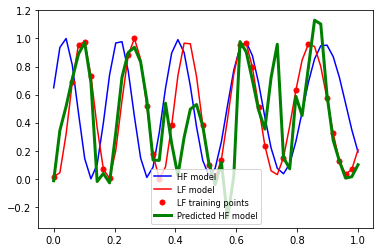

In [11]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
plt.plot(reaction_HF_test[:,0], U_HF_test, "b-", linewidth=1.5, label="HF model")
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
plt.plot(reaction_LF_test[:,0], U_LF_test, "r-", linewidth=1.5, label="LF model")
plt.plot(
    reaction_LF[:,0],
    U_LF,
    "ro",
    markersize=5,
    label="LF training points",
)
plt.plot(
    reaction_HF_test[:,0],
    finalModel.predict(reaction_HF_test),
    "g-",
    linewidth=3,
    label="Predicted HF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

#########################     SAVE the OUTPUT      ##########################
os.makedirs("NNLF_LF30_8000")

R2_HF = pandas.DataFrame({"R2_HF": [r2_HF]})
R2_LF = pandas.DataFrame({"R2_LF": [r2_LF]})
MSE_test_LF = pandas.DataFrame({"MSE_test_LF": [test_mse]})
MSE_test_HF = pandas.DataFrame({"MSE_test_HF": [test_mse_HF]})


R2_LF.to_csv(
    "./NNLF_LF30_8000/r2_HF.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
MSE_test_HF.to_csv(
    "./NNLF_LF30_8000/test_mse.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
R2_HF.to_csv(
    "./NNLF_LF30_8000/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
MSE_test_LF.to_csv(
    "./NNLF_LF30_8000/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
